In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [66]:
# --- Load data ---
df_demo = pd.read_csv("../data/demographic_data.csv") 
df_sleep = pd.read_csv("../data/Quest_sleep.csv")
df_hyp = pd.read_csv("../data/merged_demo_hypertensive_bmi_data.csv")[['Participant_ID', 'Hypertensive']]

# --- Preprocessing & Merging ---
df_sleep = df_sleep.rename(columns={'seqn_no': 'Participant_ID'})
df = df_demo.merge(df_sleep, on='Participant_ID', how='right')
df = df.merge(df_hyp, on='Participant_ID', how='inner')

In [67]:
# --- Filter valid adult records ---
df = df[(df['Age_Years'] >= 20) & df['Hypertensive'].notna() & (df['Exam_Weight'] > 0)]
df = df[df['avg_sleep_hrs'].notna() & df['Gender'].notna()]

# --- Sleep category ---
df['sleep_category'] = pd.cut(df['avg_sleep_hrs'], bins=[0, 5.9, 8, 24],
                               labels=['<6 hrs', '6-8 hrs', '>8 hrs'])
df = df[df['sleep_category'].notna()]

In [96]:
# --- CI Computation ---
def compute_weighted_ci(group):
    weights = group['Exam_Weight']
    if weights.sum() == 0:
        return pd.Series({
            'Weighted_Hypertension_Prevalence': np.nan,
            'CI_Lower': np.nan,
            'CI_Upper': np.nan,
            'Weighted_Population': 0
        })
    p = np.average(group['Hypertensive'], weights=weights)
    weight_sum = weights.sum()
    weight_sq_sum = (weights**2).sum()
    n_eff = (weight_sum ** 2) / weight_sq_sum
    se = np.sqrt(p * (1 - p) / n_eff)
    ci_lower = max(0, p - 1.96 * se)
    ci_upper = min(1, p + 1.96 * se)
    return pd.Series({
        'Weighted_Hypertension_Prevalence': p,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'Weighted_Population': weight_sum
    })

In [97]:
# --- Preprocess function ---
def preprocess_data(df, cols):
    return df[df[cols].notna().all(axis=1)]



# --- Grouped plotting function ---
def plot_grouped_prevalence_fixed(df_stats, group_col, hue_col, title):
    plt.figure(figsize=(10, 6))
    sns.set(style="whitegrid")

    df_stats['Norm_Pop'] = df_stats.groupby(group_col)['Weighted_Population'].transform(
        lambda x: x / x.max()
    )

    unique_groups = df_stats[group_col].unique()
    unique_hues = df_stats[hue_col].unique()
    n_hue = len(unique_hues)
    bar_width = 0.8 / n_hue
    positions = np.arange(len(unique_groups))

    for i, hue in enumerate(unique_hues):
        subset = df_stats[df_stats[hue_col] == hue]
        bar_pos = positions + i * bar_width - (n_hue - 1) * bar_width / 2

        plt.bar(
            bar_pos,
            subset['Weighted_Hypertension_Prevalence'],
            width=bar_width,
            label=str(hue),
            edgecolor='black'
        )

        for x, y, lower, upper, pop in zip(
            bar_pos,
            subset['Weighted_Hypertension_Prevalence'],
            subset['CI_Lower'],
            subset['CI_Upper'],
            subset['Weighted_Population']
        ):
            plt.errorbar(x, y, yerr=[[y - lower], [upper - y]], fmt='none', ecolor='black', capsize=5)
            plt.text(x, y * 0.45, f"~{int(round(pop / 1_000_000))}M", ha='center', va='center', fontsize=8)
            plt.text(x, upper + 0.02, f"{int(round(y * 100))}%", ha='center', va='bottom', fontsize=9)

    plt.title(title)
    plt.xticks(positions, [str(g).title() for g in unique_groups])
    plt.ylabel("Hypertension Prevalence")
    plt.xlabel(group_col.replace('_', ' ').title())
    plt.ylim(0, 1)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    plt.legend(title=hue_col)
    plt.tight_layout()
    plt.show()


In [ ]:
# 4. Sleep Category vs Hypertension (overall)
sleep_stats = df.groupby('sleep_category').apply(compute_weighted_ci).reset_index()
sleep_stats['Gender'] = 'All'
plot_grouped_prevalence(sleep_stats, 'sleep_category', 'Gender', "Hypertension by Sleep Duration")

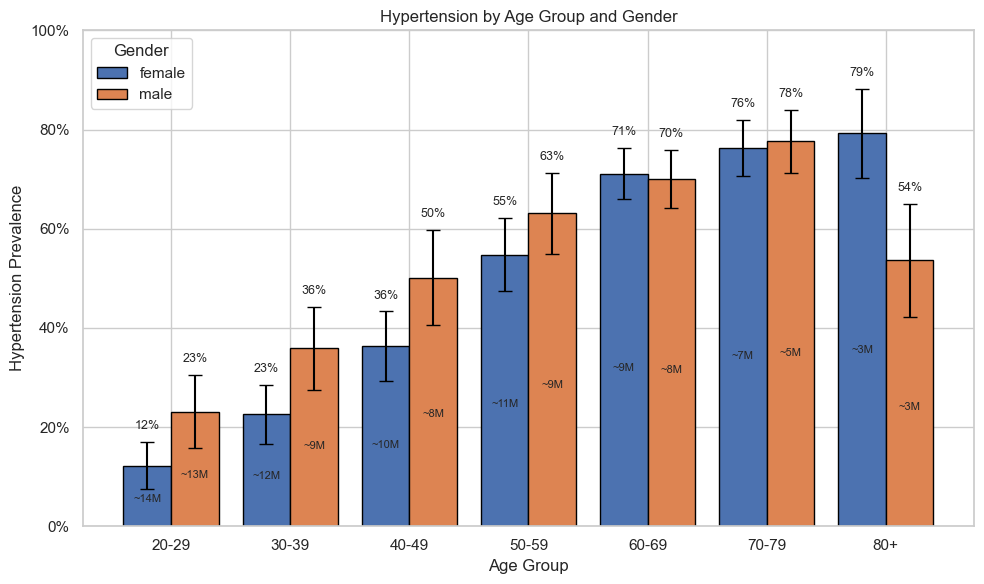

In [99]:
# Recreate Age_Group column using provided age bins and labels
age_bins = [20, 30, 40, 50, 60, 70, 80, np.inf]
age_labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']

# Apply binning on 'Age_Years' column to create 'Age_Group'
df['Age_Group'] = pd.cut(df['Age_Years'], bins=age_bins, labels=age_labels, right=False)

# Proceed with analysis and plotting
df_age_gender = preprocess_data(df, ['Age_Group', 'Gender'])
age_gender_stats = df_age_gender.groupby(['Age_Group', 'Gender']).apply(compute_weighted_ci).reset_index()
plot_grouped_prevalence_fixed(age_gender_stats, 'Age_Group', 'Gender', "Hypertension by Age Group and Gender")

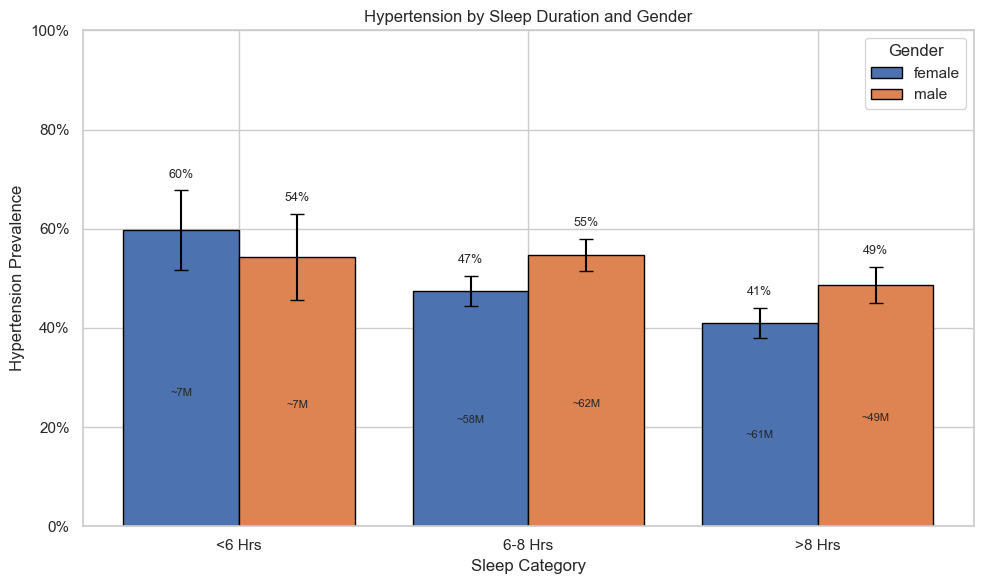

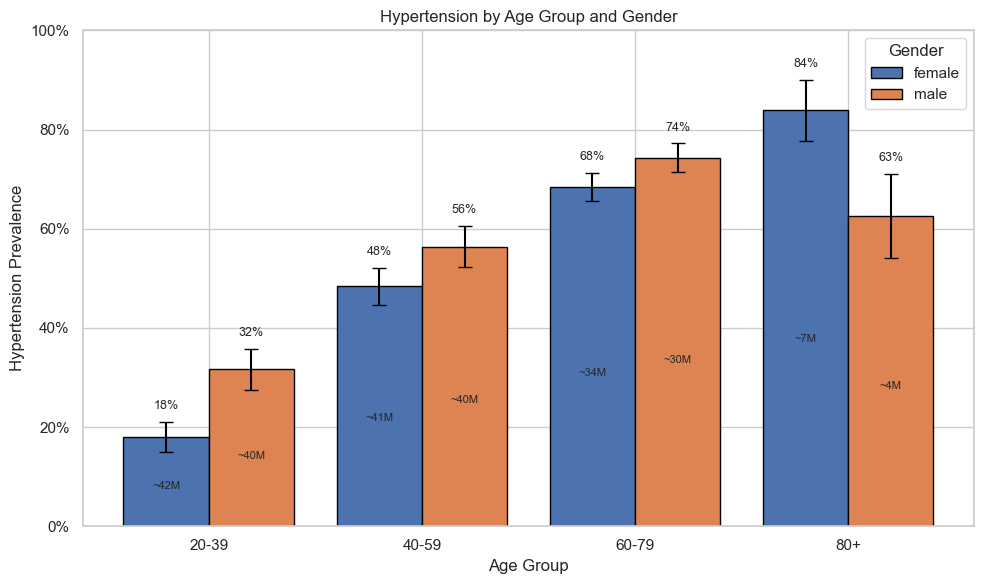

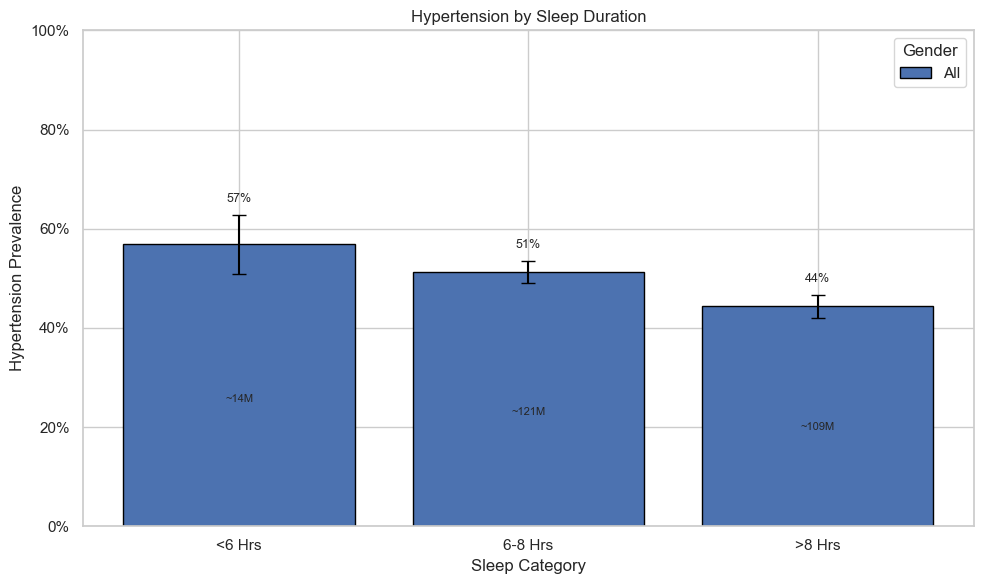

In [78]:
# 1. Sleep Category vs Gender (already computed)
plot_grouped_prevalence(grouped_stats, 'sleep_category', 'Gender', "Hypertension by Sleep Duration and Gender")

# 2. Age Group vs Hypertension (with Gender)
df['age_group'] = pd.cut(df['Age_Years'], bins=[20, 39, 59, 79, 120],
                         labels=['20-39', '40-59', '60-79', '80+'])
df_age_gender = df[df['age_group'].notna()]
age_stats = df_age_gender.groupby(['age_group', 'Gender']).apply(compute_weighted_ci).reset_index()
plot_grouped_prevalence(age_stats, 'age_group', 'Gender', "Hypertension by Age Group and Gender")

# 3. Ethnicity vs Hypertension (overall)
if 'Ethnicity' in df.columns:
    df_eth = df[df['Ethnicity'].notna()]
    eth_stats = df_eth.groupby('Ethnicity').apply(compute_weighted_ci).reset_index()
    
    # Add a dummy gender column to reuse the plotting function
    eth_stats['Gender'] = 'All'
    plot_grouped_prevalence(eth_stats, 'Ethnicity', 'Gender', "Hypertension Prevalence by Ethnicity")

# 4. Sleep Category vs Hypertension (overall)
sleep_stats = df.groupby('sleep_category').apply(compute_weighted_ci).reset_index()
sleep_stats['Gender'] = 'All'
plot_grouped_prevalence(sleep_stats, 'sleep_category', 'Gender', "Hypertension by Sleep Duration")